# 05 Classical Metrics

This notebook computes classical restoration metrics for the OpenCV Telea pilot outputs.

It uses the cleaned project structure and reusable functions from `src/restoration_eval/metrics_classical.py`.

Metrics computed:

- full-image MAE, MSE, PSNR, SSIM
- masked-region MAE, MSE, PSNR

Masked-region metrics are important because full-image metrics can hide local restoration failures when only a small part of the painting was damaged.

In [11]:
from pathlib import Path
import sys

# Robust project-root detection for running either from project root or from notebooks/
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from restoration_eval.paths import (
    CLEAN_DIR,
    MASK_DIR,
    RESTORED_OPENCV_DIR,
    PROCESSED_METADATA_DIR,
    METRICS_DIR,
)
from restoration_eval.metrics_classical import (
    compute_classical_metrics_for_restorations,
    summarize_metrics_by_mask_type,
)

METRICS_DIR.mkdir(parents=True, exist_ok=True)

RESTORATION_METADATA_PATH = PROCESSED_METADATA_DIR / "metadata_restorations_opencv_telea.csv"
CLASSICAL_METRICS_PATH = METRICS_DIR / "metrics_opencv_telea_classical.csv"

## 1. Load restoration metadata

In [13]:
restoration_metadata = pd.read_csv(RESTORATION_METADATA_PATH)
restoration_metadata.columns = restoration_metadata.columns.str.strip()

display(restoration_metadata)
print("Rows:", len(restoration_metadata))

,painting_id,mask_type,model_name,inpaint_radius,clean_filename,mask_filename,masked_filename,restored_filename,mask_area_ratio
0,p001,irregular_small,opencv_telea,3,p001_clean.png,p001_irregular_small_mask.png,p001_irregular_small_masked.png,p001_irregular_small_restored_opencv_telea.png,0.0254
1,p001,scratch_lines,opencv_telea,3,p001_clean.png,p001_scratch_lines_mask.png,p001_scratch_lines_masked.png,p001_scratch_lines_restored_opencv_telea.png,0.0233
2,p001,irregular_large,opencv_telea,3,p001_clean.png,p001_irregular_large_mask.png,p001_irregular_large_masked.png,p001_irregular_large_restored_opencv_telea.png,0.1134
3,p002,irregular_small,opencv_telea,3,p002_clean.png,p002_irregular_small_mask.png,p002_irregular_small_masked.png,p002_irregular_small_restored_opencv_telea.png,0.0274
4,p002,scratch_lines,opencv_telea,3,p002_clean.png,p002_scratch_lines_mask.png,p002_scratch_lines_masked.png,p002_scratch_lines_restored_opencv_telea.png,0.0243
5,p002,irregular_large,opencv_telea,3,p002_clean.png,p002_irregular_large_mask.png,p002_irregular_large_masked.png,p002_irregular_large_restored_opencv_telea.png,0.1129
6,p003,irregular_small,opencv_telea,3,p003_clean.png,p003_irregular_small_mask.png,p003_irregular_small_masked.png,p003_irregular_small_restored_opencv_telea.png,0.0254
7,p003,scratch_lines,opencv_telea,3,p003_clean.png,p003_scratch_lines_mask.png,p003_scratch_lines_masked.png,p003_scratch_lines_restored_opencv_telea.png,0.0158
8,p003,irregular_large,opencv_telea,3,p003_clean.png,p003_irregular_large_mask.png,p003_irregular_large_masked.png,p003_irregular_large_restored_opencv_telea.png,0.1112


Rows: 9


## 2. Compute classical metrics

In [14]:
metrics_df = compute_classical_metrics_for_restorations(
    restoration_metadata=restoration_metadata,
    clean_dir=CLEAN_DIR,
    mask_dir=MASK_DIR,
    restored_dir=RESTORED_OPENCV_DIR,
)

display(metrics_df)
print("Metric rows:", len(metrics_df))

,painting_id,mask_type,model_name,mask_area_ratio,mae,mse,psnr,ssim,mask_mae,mask_mse,mask_psnr
0,p001,irregular_small,opencv_telea,0.0254,0.119746,0.987967,48.183379,0.994996,4.714594,38.897717,32.231564
1,p001,scratch_lines,opencv_telea,0.0233,0.112400,1.660638,45.928055,0.994513,4.823983,71.271484,29.601646
2,p001,irregular_large,opencv_telea,0.1134,1.414233,36.205166,32.543098,0.967264,12.476045,319.393890,23.087538
3,p002,irregular_small,opencv_telea,0.0274,0.197944,2.610738,43.963171,0.992953,7.235071,95.425148,28.334177
4,p002,scratch_lines,opencv_telea,0.0243,0.168409,8.616002,38.777745,0.994116,6.940446,355.081390,22.627525
5,p002,irregular_large,opencv_telea,0.1129,0.999594,15.664153,36.181734,0.969453,8.857144,138.795975,26.707035
6,p003,irregular_small,opencv_telea,0.0254,0.375600,10.905023,37.754538,0.986486,14.768215,428.774353,21.808517
7,p003,scratch_lines,opencv_telea,0.0158,0.102845,1.957686,45.213373,0.995667,6.505827,123.840660,27.202169
8,p003,irregular_large,opencv_telea,0.1112,2.292114,84.357819,28.869550,0.937255,20.611731,758.583740,19.330769


Metric rows: 9


## 3. Save metric results

In [15]:
metrics_df.to_csv(CLASSICAL_METRICS_PATH, index=False)
print("Saved:", CLASSICAL_METRICS_PATH)

Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\metrics_opencv_telea_classical.csv


## 4. Inspect best and worst cases

In [16]:
metrics_sorted = metrics_df.sort_values("mask_mae", ascending=False)
display(metrics_sorted)

,painting_id,mask_type,model_name,mask_area_ratio,mae,mse,psnr,ssim,mask_mae,mask_mse,mask_psnr
8,p003,irregular_large,opencv_telea,0.1112,2.292114,84.357819,28.869550,0.937255,20.611731,758.583740,19.330769
6,p003,irregular_small,opencv_telea,0.0254,0.375600,10.905023,37.754538,0.986486,14.768215,428.774353,21.808517
2,p001,irregular_large,opencv_telea,0.1134,1.414233,36.205166,32.543098,0.967264,12.476045,319.393890,23.087538
5,p002,irregular_large,opencv_telea,0.1129,0.999594,15.664153,36.181734,0.969453,8.857144,138.795975,26.707035
3,p002,irregular_small,opencv_telea,0.0274,0.197944,2.610738,43.963171,0.992953,7.235071,95.425148,28.334177
4,p002,scratch_lines,opencv_telea,0.0243,0.168409,8.616002,38.777745,0.994116,6.940446,355.081390,22.627525
7,p003,scratch_lines,opencv_telea,0.0158,0.102845,1.957686,45.213373,0.995667,6.505827,123.840660,27.202169
1,p001,scratch_lines,opencv_telea,0.0233,0.112400,1.660638,45.928055,0.994513,4.823983,71.271484,29.601646
0,p001,irregular_small,opencv_telea,0.0254,0.119746,0.987967,48.183379,0.994996,4.714594,38.897717,32.231564


## 5. Summary by mask type

In [17]:
summary_by_mask = summarize_metrics_by_mask_type(metrics_df)
display(summary_by_mask)

,mask_type,cases,mean_mask_area_ratio,mean_mae,mean_psnr,mean_ssim,mean_mask_mae,mean_mask_mse,mean_mask_psnr
2,scratch_lines,3,0.021133,0.127884,43.306391,0.994765,6.090086,183.397845,26.477114
1,irregular_small,3,0.026067,0.231097,43.300363,0.991479,8.905960,187.699073,27.458086
0,irregular_large,3,0.112500,1.568647,32.531461,0.957991,13.981640,405.591202,23.041780


## 6. Plot masked-region MAE by mask type

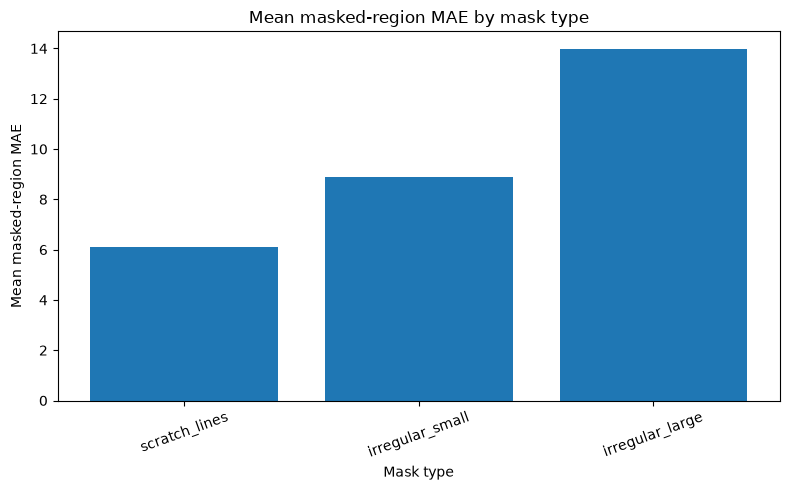

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(summary_by_mask["mask_type"], summary_by_mask["mean_mask_mae"])
plt.title("Mean masked-region MAE by mask type")
plt.xlabel("Mask type")
plt.ylabel("Mean masked-region MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 7. Plot masked-region PSNR by mask type

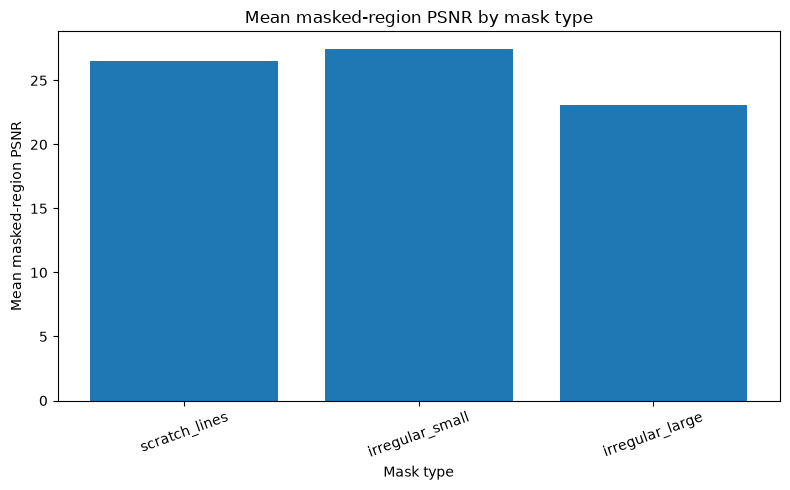

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(summary_by_mask["mask_type"], summary_by_mask["mean_mask_psnr"])
plt.title("Mean masked-region PSNR by mask type")
plt.xlabel("Mask type")
plt.ylabel("Mean masked-region PSNR")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 8. Compact metric table

In [20]:
compact_columns = [
    "painting_id",
    "mask_type",
    "mask_area_ratio",
    "mae",
    "mask_mae",
    "psnr",
    "mask_psnr",
    "ssim",
]

display(metrics_df[compact_columns].sort_values(["painting_id", "mask_type"]))

,painting_id,mask_type,mask_area_ratio,mae,mask_mae,psnr,mask_psnr,ssim
2,p001,irregular_large,0.1134,1.414233,12.476045,32.543098,23.087538,0.967264
0,p001,irregular_small,0.0254,0.119746,4.714594,48.183379,32.231564,0.994996
1,p001,scratch_lines,0.0233,0.112400,4.823983,45.928055,29.601646,0.994513
5,p002,irregular_large,0.1129,0.999594,8.857144,36.181734,26.707035,0.969453
3,p002,irregular_small,0.0274,0.197944,7.235071,43.963171,28.334177,0.992953
4,p002,scratch_lines,0.0243,0.168409,6.940446,38.777745,22.627525,0.994116
8,p003,irregular_large,0.1112,2.292114,20.611731,28.869550,19.330769,0.937255
6,p003,irregular_small,0.0254,0.375600,14.768215,37.754538,21.808517,0.986486
7,p003,scratch_lines,0.0158,0.102845,6.505827,45.213373,27.202169,0.995667


## Completion check

Expected output:

```text
outputs/metrics/metrics_opencv_telea_classical.csv
```

Expected row count:

```text
9 rows = 3 paintings × 3 mask types × 1 model
```